In [1]:
## ======================================================
## 🛍️ Hopify Top Cross-Sell Product Categories by Segment
## ======================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📤 Load Data
## ==================================================

In [3]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "03_Project_Product_Cust_Behavior_Insights",
    "05_hopify_top_cross_sell_prod_combo_seg.csv"
)

df = pd.read_csv(file_path)

## ==================================================
## 🧼 Clean & Format Dataframe
## ==================================================

In [4]:
# Clean and standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Filter out rows with zero frequency
df = df[df["combo_frequency"] > 0]


# Select top 2 combos per segment
top2 = (
    df.sort_values(["customer_segment", "combo_frequency"], ascending=[True, False])
      .groupby("customer_segment")
      .head(2)
)

## ==================================================
## Plot
## ==================================================

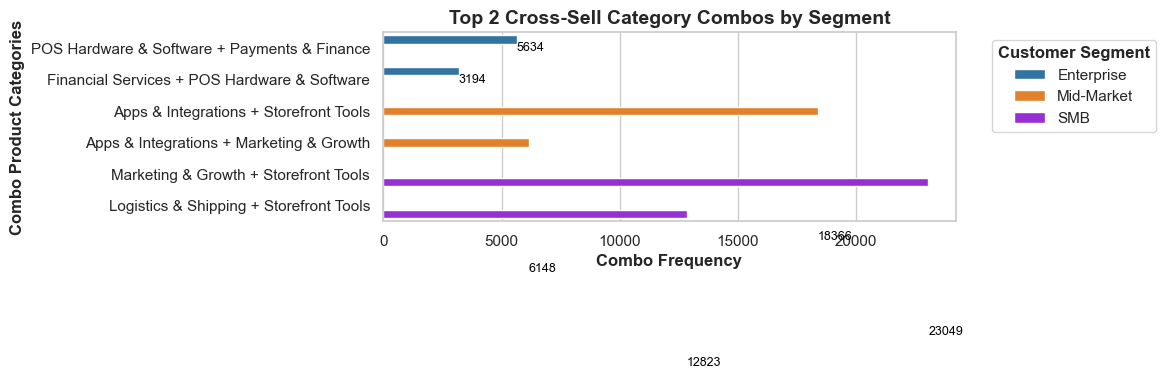

In [5]:
custom_palette = {
    "Enterprise": "#1f77b4",    # blue
    "Mid-Market": "#ff7f0e",    # orange
    "SMB": "#9f13ef"            # purple
}

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top2,
    y="category_combo",
    x="combo_frequency",
    hue="customer_segment",
    dodge=True,
    palette=custom_palette
)

# Add value labels
for i, row in top2.iterrows():
    ax.text(
        row["combo_frequency"] + 0.5,
        i,
        f"{int(row['combo_frequency'])}",
        color="black", va="center", fontsize=9
    )

# Format layout
bold_title = FontProperties(weight='bold')
plt.title("Top 2 Cross-Sell Category Combos by Segment", fontsize=14, fontweight='bold')
plt.xlabel("Combo Frequency", fontweight='bold')
plt.ylabel("Combo Product Categories", fontweight='bold')
plt.legend(title="Customer Segment", title_fontproperties=bold_title, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

## ==================================================
## 📊 Save & Display Plot
## ==================================================

In [6]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "03_project_product_cust_behavior_insights",
    "hopify_top_cross_sell_combos_by_segment.png"
)
plt.savefig(output_path, dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>